<a href="https://colab.research.google.com/github/Digital-Marketing-Genius/Churn_management/blob/main/DATA5000_Churn_Prediction_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA5000 – Customer Churn Prediction
**Sprott School of Business, Carleton University**
Team: Oluwatayo Alofun | Adeyeye Adedayo | Kyle Bruinsma | Kumuditha Udugama

### Notebook Sections
1. Library Installation & Imports
2. Data Loading & Initial Review
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Sampling
5. Machine Learning Modeling
6. Model Evaluation & Results

In [ ]:
# Run this cell first every session
!pip install scikit-learn pandas numpy matplotlib seaborn imbalanced-learn statsmodels --quiet

In [ ]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, roc_auc_score,
                             f1_score, precision_score, recall_score, accuracy_score)
from sklearn.preprocessing import StandardScaler

# Sampling
from imblearn.over_sampling import SMOTE

# Statistics (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/DATA5000 Churn Project/'
print("Drive mounted. Project path set to:", PROJECT_PATH)

Mounted at /content/drive
Drive mounted. Project path set to: /content/drive/MyDrive/DATA5000 Churn Project/


In [ ]:
import sklearn, imblearn, statsmodels
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("statsmodels:", statsmodels.__version__)

scikit-learn: 1.6.1
imbalanced-learn: 0.14.1
pandas: 2.2.2
numpy: 2.0.2
statsmodels: 0.14.6


## Section 2: Data Loading & Initial Review

In [ ]:
# Load the dataset from Google Drive
df = pd.read_csv(PROJECT_PATH + 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset loaded successfully.
Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
# Check the churn distribution
print("Churn value counts:")
print(df['Churn'].value_counts())
print()
print("Churn rate:")
print(df['Churn'].value_counts(normalize=True).round(4) * 100, "%")

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64 %


In [ ]:
# Preview the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Check data types and missing values
print("Data types and non-null counts:")
print(df.info())
print()
print("Missing values per column:")
print(df.isnull().sum())

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessB

## Section 3: Exploratory Data Analysis (EDA)
### Task 6: Descriptive Statistics

In [ ]:
# Summary statistics for all numeric columns
print("Summary Statistics for Numeric Columns:")
df.describe().round(2)

Summary Statistics for Numeric Columns:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [ ]:
# Summary of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)
print()

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

--- customerID ---
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: i

In [ ]:
# Churn rate by contract type
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
print("Churn rate by Contract Type:")
print(churn_by_contract.round(3) * 100)

Churn rate by Contract Type:
Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


In [ ]:
# Group tenure into bands and check churn rate
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-12 months', '13-24 months',
                                     '25-48 months', '49-72 months'])

churn_by_tenure = df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack()
print("Churn rate by Tenure Group:")
print(churn_by_tenure.round(3) * 100)

Churn rate by Tenure Group:
Churn           No   Yes
tenure_group            
0-12 months   52.3  47.7
13-24 months  71.3  28.7
25-48 months  79.6  20.4
49-72 months  90.5   9.5


/tmp/ipykernel_252/1846452821.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack()


In [ ]:
# TotalCharges was imported as object (text) - convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values appeared after conversion
print("Missing values in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# These are new customers with zero tenure - fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Missing values after fix:", df['TotalCharges'].isnull().sum())
print("TotalCharges column is now ready.")

Missing values in TotalCharges after conversion: 11
Missing values after fix: 0
TotalCharges column is now ready.


In [ ]:
# Confirm zero missing values across entire dataset
print("Missing values across all columns:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())

Missing values across all columns:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges         0
Churn                0
tenure_group        11
dtype: int64

Total missing values: 11


In [ ]:
# Fix tenure_group bins to include customers with 0 tenure
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[-1, 12, 24, 48, 72],
                             labels=['0-12 months', '13-24 months',
                                     '25-48 months', '49-72 months'])

# Confirm fix
print("Missing values in tenure_group:", df['tenure_group'].isnull().sum())
print()
print("Tenure group distribution:")
print(df['tenure_group'].value_counts().sort_index())

Missing values in tenure_group: 0

Tenure group distribution:
tenure_group
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64


### Task 7: Visualizations

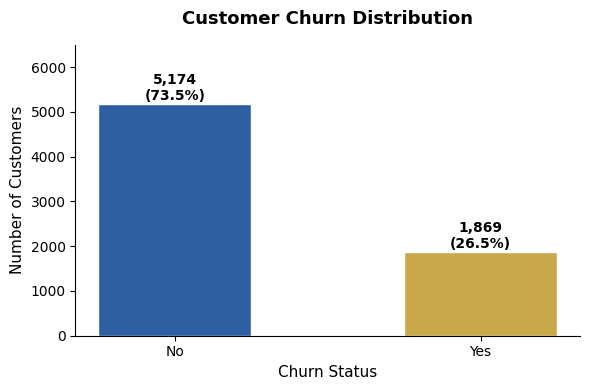

Chart 1 saved.


In [ ]:
# Chart 1: Overall Churn Distribution
fig, ax = plt.subplots(figsize=(6, 4))

churn_counts = df['Churn'].value_counts()
colors = ['#2E5FA3', '#C9A84C']

bars = ax.bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', width=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Customer Churn Distribution', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Churn Status', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_ylim(0, 6500)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PROJECT_PATH + 'chart1_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

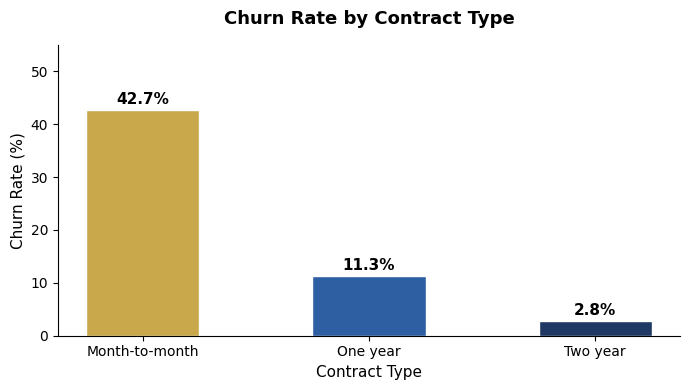

Chart 2 saved.


In [ ]:
# Chart 2: Churn Rate by Contract Type
fig, ax = plt.subplots(figsize=(7, 4))

churn_contract = df[df['Churn'] == 'Yes']['Contract'].value_counts()
total_contract = df['Contract'].value_counts()
churn_rate_contract = (churn_contract / total_contract * 100).sort_values(ascending=False)

bars = ax.bar(churn_rate_contract.index, churn_rate_contract.values,
              color=['#C9A84C', '#2E5FA3', '#1F3864'], edgecolor='white', width=0.5)

for bar, val in zip(bars, churn_rate_contract.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Contract Type', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 55)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PROJECT_PATH + 'chart2_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

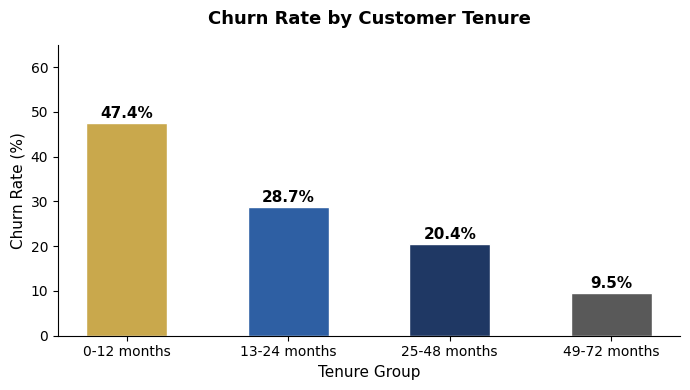

Chart 3 saved.


In [ ]:
# Chart 3: Churn Rate by Tenure Group
fig, ax = plt.subplots(figsize=(7, 4))

churn_tenure = df[df['Churn'] == 'Yes']['tenure_group'].value_counts()
total_tenure = df['tenure_group'].value_counts()
churn_rate_tenure = (churn_tenure / total_tenure * 100).sort_index()

bars = ax.bar(churn_rate_tenure.index.astype(str), churn_rate_tenure.values,
              color=['#C9A84C', '#2E5FA3', '#1F3864', '#595959'],
              edgecolor='white', width=0.5)

for bar, val in zip(bars, churn_rate_tenure.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Customer Tenure', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Tenure Group', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 65)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PROJECT_PATH + 'chart3_churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

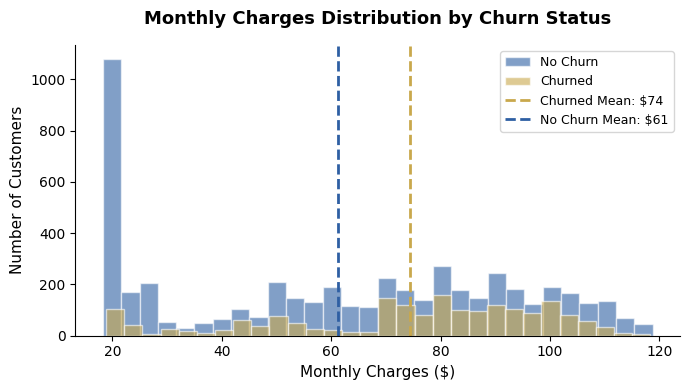

Chart 4 saved.


In [ ]:
# Chart 4: Monthly Charges by Churn Status
fig, ax = plt.subplots(figsize=(7, 4))

churned = df[df['Churn'] == 'Yes']['MonthlyCharges']
not_churned = df[df['Churn'] == 'No']['MonthlyCharges']

ax.hist(not_churned, bins=30, alpha=0.6, color='#2E5FA3', label='No Churn', edgecolor='white')
ax.hist(churned, bins=30, alpha=0.6, color='#C9A84C', label='Churned', edgecolor='white')

ax.axvline(churned.mean(), color='#C9A84C', linestyle='--', linewidth=2,
           label=f'Churned Mean: ${churned.mean():.0f}')
ax.axvline(not_churned.mean(), color='#2E5FA3', linestyle='--', linewidth=2,
           label=f'No Churn Mean: ${not_churned.mean():.0f}')

ax.set_title('Monthly Charges Distribution by Churn Status', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Monthly Charges ($)', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PROJECT_PATH + 'chart4_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

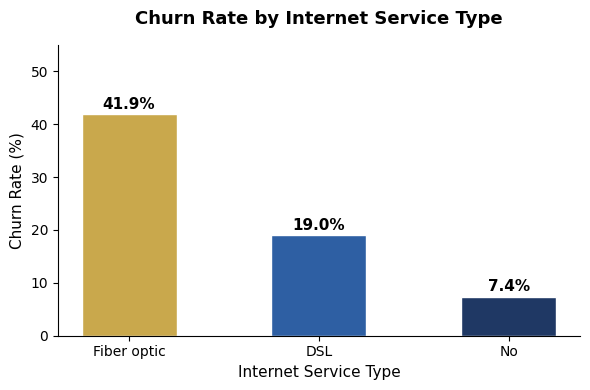

Chart 5 saved.


In [ ]:
# Chart 5: Churn Rate by Internet Service
fig, ax = plt.subplots(figsize=(6, 4))

churn_internet = df[df['Churn'] == 'Yes']['InternetService'].value_counts()
total_internet = df['InternetService'].value_counts()
churn_rate_internet = (churn_internet / total_internet * 100).sort_values(ascending=False)

bars = ax.bar(churn_rate_internet.index, churn_rate_internet.values,
              color=['#C9A84C', '#2E5FA3', '#1F3864'], edgecolor='white', width=0.5)

for bar, val in zip(bars, churn_rate_internet.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Internet Service Type', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Internet Service Type', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 55)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PROJECT_PATH + 'chart5_churn_by_internet.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")

### Task 9: Multicollinearity Check (VIF Analysis)

In [ ]:
# VIF can only be run on numeric columns
# Select only the numeric columns from the dataset
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Build a small dataframe of just those columns
vif_data = df[numeric_cols].copy()

# Calculate VIF for each column
vif_results = pd.DataFrame()
vif_results['Variable'] = numeric_cols
vif_results['VIF'] = [variance_inflation_factor(vif_data.values, i)
                       for i in range(len(numeric_cols))]

vif_results['Status'] = vif_results['VIF'].apply(
    lambda x: '✓ OK' if x < 5 else ('⚠ Monitor' if x < 10 else '✗ Problematic'))

print("VIF Results:")
print(vif_results.round(2))

VIF Results:
         Variable   VIF     Status
0          tenure  6.33  ⚠ Monitor
1  MonthlyCharges  3.36       ✓ OK
2    TotalCharges  8.08  ⚠ Monitor


In [ ]:
# Flag any problematic columns
problematic = vif_results[vif_results['VIF'] > 10]

if len(problematic) > 0:
    print("⚠ The following columns have high multicollinearity (VIF > 10):")
    print(problematic[['Variable', 'VIF']])
    print()
    print("Recommendation: Consider dropping TotalCharges since it is")
    print("mathematically derived from tenure x MonthlyCharges.")
else:
    print("✓ No problematic multicollinearity detected. All VIF values are acceptable.")

✓ No problematic multicollinearity detected. All VIF values are acceptable.


In [ ]:
# Drop TotalCharges - moderately high VIF (8.08) and it is derived
# from tenure x MonthlyCharges, so it adds redundant information
df = df.drop(columns=['TotalCharges'])

print("TotalCharges column removed.")
print("Dataset shape is now:", df.shape)

TotalCharges column removed.
Dataset shape is now: (7043, 21)


In [ ]:
# Re-run VIF with TotalCharges removed to confirm improvement
numeric_cols_final = ['tenure', 'MonthlyCharges']

vif_final = pd.DataFrame()
vif_final['Variable'] = numeric_cols_final
vif_final['VIF'] = [variance_inflation_factor(
                    df[numeric_cols_final].values, i)
                    for i in range(len(numeric_cols_final))]

vif_final['Status'] = vif_final['VIF'].apply(
    lambda x: '✓ OK' if x < 5 else ('⚠ Monitor' if x < 10 else '✗ Problematic'))

print("Final VIF Results after removing TotalCharges:")
print(vif_final.round(2))

Final VIF Results after removing TotalCharges:
         Variable   VIF Status
0          tenure  2.61   ✓ OK
1  MonthlyCharges  2.61   ✓ OK


## Section 4: Data Preprocessing & Sampling
### Task 11: Categorical Encoding & Log Transforms

In [ ]:
# Convert Churn from Yes/No text to 1/0 numbers
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn column converted:")
print(df['Churn'].value_counts())
print()
print("0 = Did not churn, 1 = Churned")

Churn column converted:
Churn
0    5174
1    1869
Name: count, dtype: int64

0 = Did not churn, 1 = Churned


In [ ]:
# Drop columns not needed for modeling
df = df.drop(columns=['customerID', 'tenure_group'])

print("Unnecessary columns removed.")
print("Dataset shape:", df.shape)
print("Remaining columns:", df.columns.tolist())

Unnecessary columns removed.
Dataset shape: (7043, 19)
Remaining columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn']


In [ ]:
# Apply log transform to continuous variables
# np.log1p is used instead of np.log to safely handle any zero values
df['tenure_log'] = np.log1p(df['tenure'])
df['MonthlyCharges_log'] = np.log1p(df['MonthlyCharges'])

# Drop the original untransformed columns
df = df.drop(columns=['tenure', 'MonthlyCharges'])

print("Log transforms applied.")
print("New columns added: tenure_log, MonthlyCharges_log")
print("Dataset shape:", df.shape)

Log transforms applied.
New columns added: tenure_log, MonthlyCharges_log
Dataset shape: (7043, 19)


In [ ]:
# Identify remaining categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)
print("Count:", len(cat_cols))

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Count: 15


In [ ]:
# Apply one-hot encoding to all categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Encoding complete.")
print("Dataset shape after encoding:", df_encoded.shape)
print()
print("All columns:")
print(df_encoded.columns.tolist())

Encoding complete.
Dataset shape after encoding: (7043, 30)

All columns:
['SeniorCitizen', 'Churn', 'tenure_log', 'MonthlyCharges_log', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [ ]:
# Final confirmation of clean, encoded dataset
print("Final dataset summary:")
print("Shape:", df_encoded.shape)
print("Missing values:", df_encoded.isnull().sum().sum())
print("Churn distribution:")
print(df_encoded['Churn'].value_counts())
print()
print("Data types - all should be numeric:")
print(df_encoded.dtypes.value_counts())

Final dataset summary:
Shape: (7043, 30)
Missing values: 0
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Data types - all should be numeric:
bool       26
int64       2
float64     2
Name: count, dtype: int64


### Task 12: Train/Validation/Test Split (60/20/20, Stratified)

In [ ]:
# Separate features (X) from target variable (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print()
print("Churn rate in full dataset:", round(y.mean() * 100, 2), "%")

Features (X) shape: (7043, 29)
Target (y) shape: (7043,)

Churn rate in full dataset: 26.54 %


In [ ]:
# First split: 60% training, 40% remaining (which will become val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Remaining set shape:", X_temp.shape)
print()
print("Churn rate in training set:", round(y_train.mean() * 100, 2), "%")
print("Churn rate in remaining set:", round(y_temp.mean() * 100, 2), "%")

Training set shape: (4225, 29)
Remaining set shape: (2818, 29)

Churn rate in training set: 26.53 %
Churn rate in remaining set: 26.54 %


In [ ]:
# Second split: split the remaining 40% equally into 20% val and 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)
print()
print("Churn rate in validation set:", round(y_val.mean() * 100, 2), "%")
print("Churn rate in test set:", round(y_test.mean() * 100, 2), "%")

Validation set shape: (1409, 29)
Test set shape: (1409, 29)

Churn rate in validation set: 26.54 %
Churn rate in test set: 26.54 %


In [ ]:
# Final confirmation of all three splits
total = len(X)

print("DATASET SPLIT SUMMARY")
print("-" * 40)
print(f"Full dataset:      {total} rows (100%)")
print(f"Training set:      {len(X_train)} rows ({len(X_train)/total*100:.0f}%)")
print(f"Validation set:    {len(X_val)} rows ({len(X_val)/total*100:.0f}%)")
print(f"Test set:          {len(X_test)} rows ({len(X_test)/total*100:.0f}%)")
print("-" * 40)
print()
print("Churn rate consistency check:")
print(f"Full dataset:   {y.mean()*100:.2f}%")
print(f"Training set:   {y_train.mean()*100:.2f}%")
print(f"Validation set: {y_val.mean()*100:.2f}%")
print(f"Test set:       {y_test.mean()*100:.2f}%")
print()
print("All splits ready for modeling.")

DATASET SPLIT SUMMARY
----------------------------------------
Full dataset:      7043 rows (100%)
Training set:      4225 rows (60%)
Validation set:    1409 rows (20%)
Test set:          1409 rows (20%)
----------------------------------------

Churn rate consistency check:
Full dataset:   26.54%
Training set:   26.53%
Validation set: 26.54%
Test set:       26.54%

All splits ready for modeling.


### Tasks 13-17: Sampling Configurations & Prevalence Inflation

In [ ]:
# CONFIG 1: No sampling - use training data as-is
X_train_c1 = X_train.copy()
y_train_c1 = y_train.copy()

print("CONFIG 1: No Sampling (Baseline)")
print("-" * 40)
print(f"Training set size:  {len(X_train_c1)}")
print(f"Churners (1):       {y_train_c1.sum()}")
print(f"Non-churners (0):   {(y_train_c1 == 0).sum()}")
print(f"Churn rate:         {y_train_c1.mean()*100:.2f}%")

CONFIG 1: No Sampling (Baseline)
----------------------------------------
Training set size:  4225
Churners (1):       1121
Non-churners (0):   3104
Churn rate:         26.53%


In [ ]:
# CONFIG 2: SMOTE oversampling - 50/50 equal split
smote_5050 = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_c2, y_train_c2 = smote_5050.fit_resample(X_train, y_train)

print("CONFIG 2: SMOTE 50/50 Oversampling")
print("-" * 40)
print(f"Training set size:  {len(X_train_c2)}")
print(f"Churners (1):       {y_train_c2.sum()}")
print(f"Non-churners (0):   {(y_train_c2 == 0).sum()}")
print(f"Churn rate:         {y_train_c2.mean()*100:.2f}%")

CONFIG 2: SMOTE 50/50 Oversampling
----------------------------------------
Training set size:  6208
Churners (1):       3104
Non-churners (0):   3104
Churn rate:         50.00%


In [ ]:
# CONFIG 3: SMOTE oversampling - 30/70 churn to non-churn ratio
smote_3070 = SMOTE(sampling_strategy=0.4286, random_state=42)
X_train_c3, y_train_c3 = smote_3070.fit_resample(X_train, y_train)

print("CONFIG 3: SMOTE 30/70 Oversampling")
print("-" * 40)
print(f"Training set size:  {len(X_train_c3)}")
print(f"Churners (1):       {y_train_c3.sum()}")
print(f"Non-churners (0):   {(y_train_c3 == 0).sum()}")
print(f"Churn rate:         {y_train_c3.mean()*100:.2f}%")

CONFIG 3: SMOTE 30/70 Oversampling
----------------------------------------
Training set size:  4434
Churners (1):       1330
Non-churners (0):   3104
Churn rate:         30.00%


In [ ]:
# CONFIG 4: Manual stratified undersampling
# Keep all churners, randomly sample 60% of non-churners

# Separate churners and non-churners from training set
train_data = X_train.copy()
train_data['Churn'] = y_train.values

churners = train_data[train_data['Churn'] == 1]
non_churners = train_data[train_data['Churn'] == 0]

# Print original counts so we can see what we are working with
print(f"Original churners in training:     {len(churners)}")
print(f"Original non-churners in training: {len(non_churners)}")
print()

# Sample 60% of non-churners with fixed seed for reproducibility
non_churners_sampled = non_churners.sample(
    frac=0.60, random_state=42)

# Combine back together
train_undersampled = pd.concat([churners, non_churners_sampled])

# Separate back into X and y
X_train_c4 = train_undersampled.drop(columns=['Churn'])
y_train_c4 = train_undersampled['Churn']

print("CONFIG 4: Manual Stratified Undersampling")
print("-" * 40)
print(f"Training set size:  {len(X_train_c4)}")
print(f"Churners (1):       {y_train_c4.sum()}")
print(f"Non-churners (0):   {(y_train_c4 == 0).sum()}")
print(f"Churn rate:         {y_train_c4.mean()*100:.2f}%")

Original churners in training:     1121
Original non-churners in training: 3104

CONFIG 4: Manual Stratified Undersampling
----------------------------------------
Training set size:  2983
Churners (1):       1121
Non-churners (0):   1862
Churn rate:         37.58%


In [ ]:
# Task 17: Compute prevalence inflation factors for all 4 configs
baseline_rate = y_train_c1.mean()

configs = {
    'Config 1: No Sampling':          y_train_c1,
    'Config 2: SMOTE 50/50':          y_train_c2,
    'Config 3: SMOTE 30/70':          y_train_c3,
    'Config 4: Manual Undersampling': y_train_c4,
}

print("PREVALENCE INFLATION TABLE")
print("=" * 65)
print(f"{'Configuration':<35} {'Churn Rate':>12} {'Inflation Factor':>16}")
print("-" * 65)

for name, y_config in configs.items():
    rate = y_config.mean()
    inflation = rate / baseline_rate
    print(f"{name:<35} {rate*100:>11.2f}% {inflation:>16.2f}x")

print("=" * 65)
print(f"\nBaseline real-world churn rate: {baseline_rate*100:.2f}%")
print("Inflation factor = Config churn rate / Baseline churn rate")

PREVALENCE INFLATION TABLE
Configuration                         Churn Rate Inflation Factor
-----------------------------------------------------------------
Config 1: No Sampling                     26.53%             1.00x
Config 2: SMOTE 50/50                     50.00%             1.88x
Config 3: SMOTE 30/70                     30.00%             1.13x
Config 4: Manual Undersampling            37.58%             1.42x

Baseline real-world churn rate: 26.53%
Inflation factor = Config churn rate / Baseline churn rate


## Section 5: Machine Learning Modeling
### Task 18: Logistic Regression - All 4 Sampling Configurations

In [ ]:
# Train Logistic Regression on all 4 sampling configurations
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)

# Store all results here
lr_results = {}

configs_lr = {
    'Config 1: No Sampling':          (X_train_c1, y_train_c1),
    'Config 2: SMOTE 50/50':          (X_train_c2, y_train_c2),
    'Config 3: SMOTE 30/70':          (X_train_c3, y_train_c3),
    'Config 4: Manual Undersampling': (X_train_c4, y_train_c4),
}

for config_name, (X_tr, y_tr) in configs_lr.items():
    # Train the model
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_tr, y_tr)

    # Predict on test set
    y_pred = lr_model.predict(X_test)
    y_prob = lr_model.predict_proba(X_test)[:, 1]

    # Store results
    lr_results[config_name] = {
        'model':     lr_model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'auc':       roc_auc_score(y_test, y_prob),
    }
    print(f"✓ Trained: {config_name}")

print()
print("All 4 Logistic Regression models trained successfully.")

✓ Trained: Config 1: No Sampling
✓ Trained: Config 2: SMOTE 50/50
✓ Trained: Config 3: SMOTE 30/70
✓ Trained: Config 4: Manual Undersampling

All 4 Logistic Regression models trained successfully.


In [ ]:
# Print performance metrics for all 4 LR configs
print("LOGISTIC REGRESSION - PERFORMANCE COMPARISON TABLE")
print("=" * 85)
print(f"{'Configuration':<35} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 85)

for config_name, metrics in lr_results.items():
    print(f"{config_name:<35} "
          f"{metrics['accuracy']*100:>8.2f}% "
          f"{metrics['precision']*100:>9.2f}% "
          f"{metrics['recall']*100:>7.2f}% "
          f"{metrics['f1']*100:>7.2f}% "
          f"{metrics['auc']*100:>7.2f}%")

print("=" * 85)

LOGISTIC REGRESSION - PERFORMANCE COMPARISON TABLE
Configuration                        Accuracy  Precision   Recall       F1      AUC
-------------------------------------------------------------------------------------
Config 1: No Sampling                  79.77%     65.29%   50.80%   57.14%   84.00%
Config 2: SMOTE 50/50                  73.31%     49.81%   71.93%   58.86%   82.15%
Config 3: SMOTE 30/70                  79.70%     62.94%   57.22%   59.94%   83.82%
Config 4: Manual Undersampling         77.08%     55.58%   67.91%   61.13%   83.73%


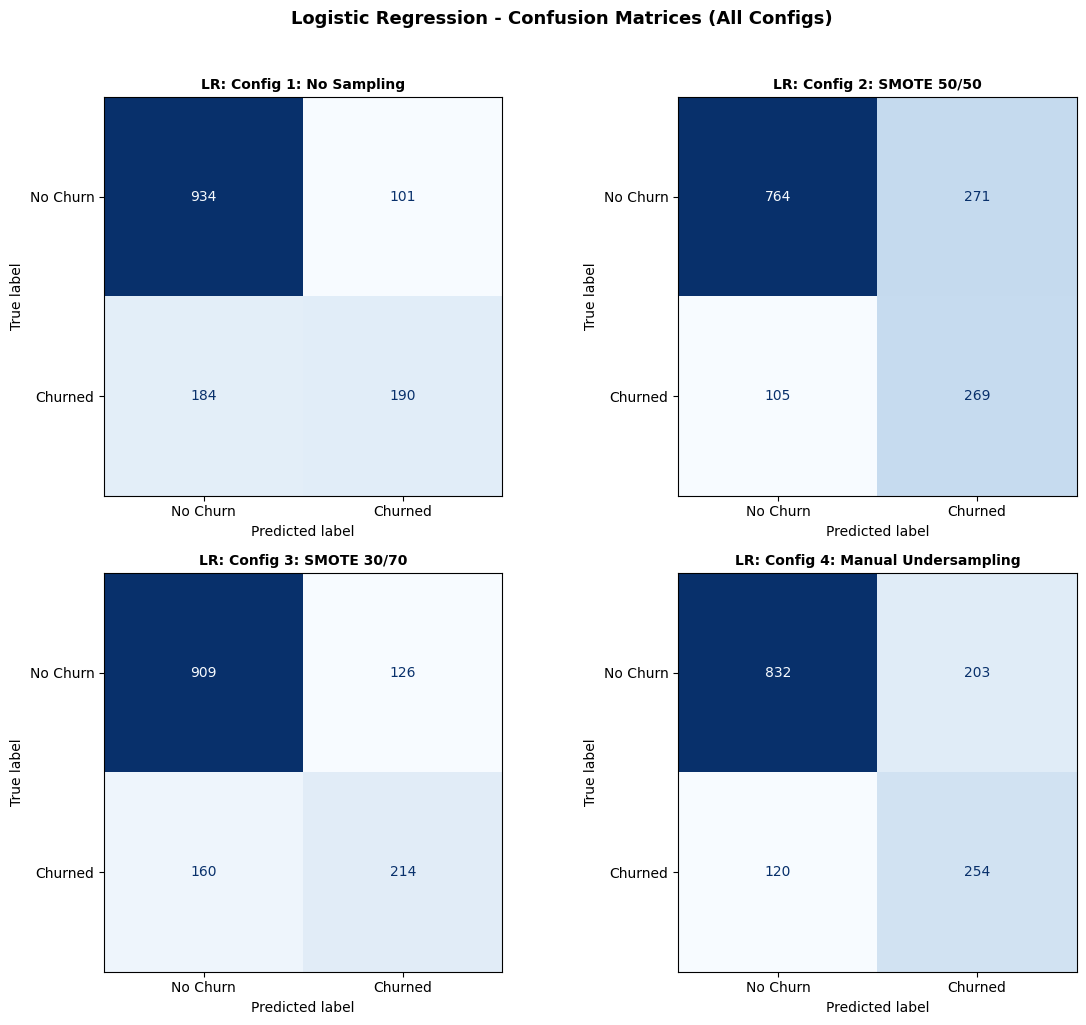

Confusion matrices saved.


In [ ]:
# Generate confusion matrices for all 4 LR configs
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (config_name, metrics) in enumerate(lr_results.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Churn', 'Churned'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'LR: {config_name}', fontsize=10, fontweight='bold')

plt.suptitle('Logistic Regression - Confusion Matrices (All Configs)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_PATH + 'lr_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved.")

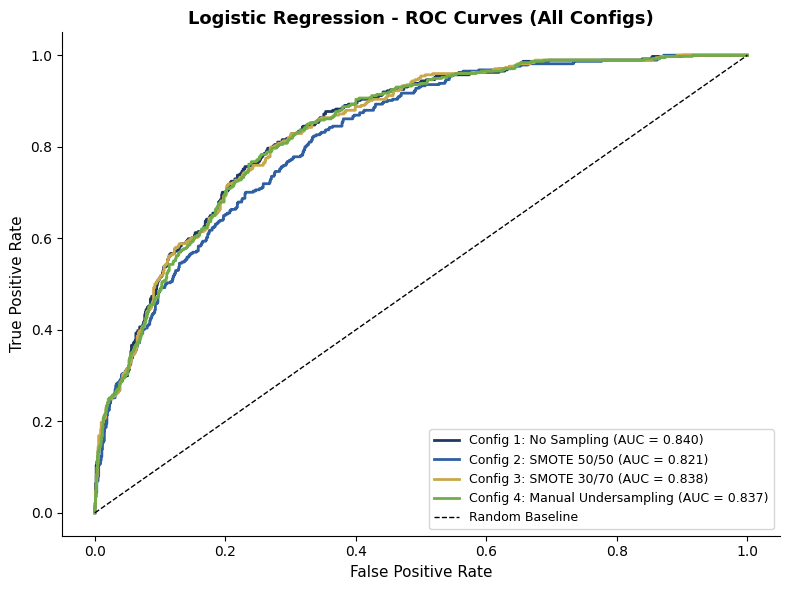

ROC curves saved.


In [ ]:
# ROC curves for all 4 LR configs
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1F3864', '#2E5FA3', '#C9A84C', '#70AD47']

for (config_name, metrics), color in zip(lr_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, metrics['y_prob'])
    auc_score = metrics['auc']
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{config_name} (AUC = {auc_score:.3f})")

# Diagonal baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')

ax.set_title('Logistic Regression - ROC Curves (All Configs)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PROJECT_PATH + 'lr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves saved.")

### Task 19: Random Forest - All 4 Sampling Configurations

In [ ]:
# Train Random Forest on all 4 sampling configurations
from sklearn.ensemble import RandomForestClassifier

# Store all results here
rf_results = {}

configs_rf = {
    'Config 1: No Sampling':          (X_train_c1, y_train_c1),
    'Config 2: SMOTE 50/50':          (X_train_c2, y_train_c2),
    'Config 3: SMOTE 30/70':          (X_train_c3, y_train_c3),
    'Config 4: Manual Undersampling': (X_train_c4, y_train_c4),
}

for config_name, (X_tr, y_tr) in configs_rf.items():
    # Train the model
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_tr, y_tr)

    # Predict on test set
    y_pred = rf_model.predict(X_test)
    y_prob = rf_model.predict_proba(X_test)[:, 1]

    # Store results
    rf_results[config_name] = {
        'model':     rf_model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'auc':       roc_auc_score(y_test, y_prob),
    }
    print(f"✓ Trained: {config_name}")

print()
print("All 4 Random Forest models trained successfully.")

✓ Trained: Config 1: No Sampling
✓ Trained: Config 2: SMOTE 50/50
✓ Trained: Config 3: SMOTE 30/70
✓ Trained: Config 4: Manual Undersampling

All 4 Random Forest models trained successfully.


In [ ]:
# Print performance metrics for all 4 RF configs
print("RANDOM FOREST - PERFORMANCE COMPARISON TABLE")
print("=" * 85)
print(f"{'Configuration':<35} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 85)

for config_name, metrics in rf_results.items():
    print(f"{config_name:<35} "
          f"{metrics['accuracy']*100:>8.2f}% "
          f"{metrics['precision']*100:>9.2f}% "
          f"{metrics['recall']*100:>7.2f}% "
          f"{metrics['f1']*100:>7.2f}% "
          f"{metrics['auc']*100:>7.2f}%")

print("=" * 85)

RANDOM FOREST - PERFORMANCE COMPARISON TABLE
Configuration                        Accuracy  Precision   Recall       F1      AUC
-------------------------------------------------------------------------------------
Config 1: No Sampling                  77.86%     61.07%   45.72%   52.29%   80.41%
Config 2: SMOTE 50/50                  75.44%     53.29%   60.70%   56.75%   79.80%
Config 3: SMOTE 30/70                  76.72%     57.10%   49.47%   53.01%   80.32%
Config 4: Manual Undersampling         76.22%     54.65%   61.23%   57.76%   80.58%


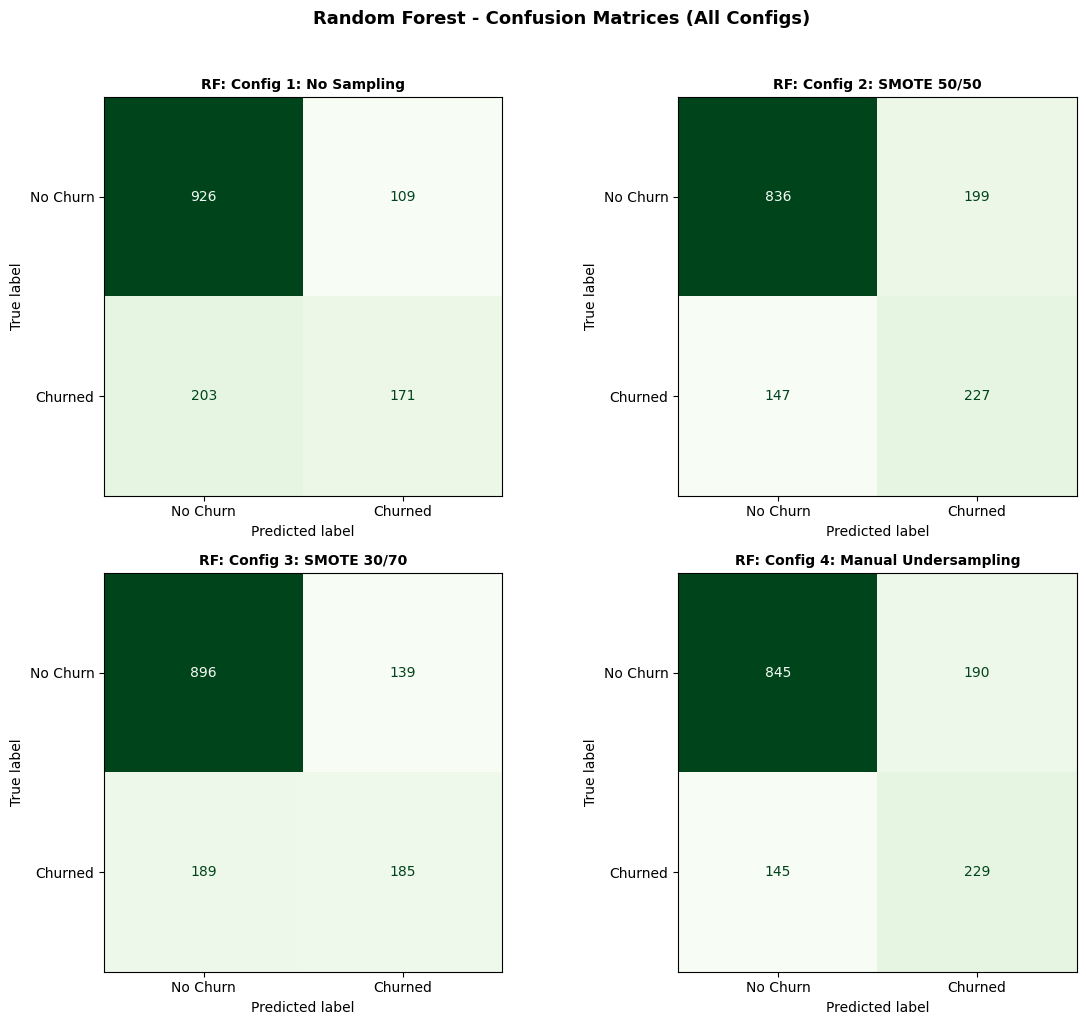

RF confusion matrices saved.


In [ ]:
# Generate confusion matrices for all 4 RF configs
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (config_name, metrics) in enumerate(rf_results.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Churn', 'Churned'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Greens')
    axes[i].set_title(f'RF: {config_name}', fontsize=10, fontweight='bold')

plt.suptitle('Random Forest - Confusion Matrices (All Configs)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_PATH + 'rf_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("RF confusion matrices saved.")

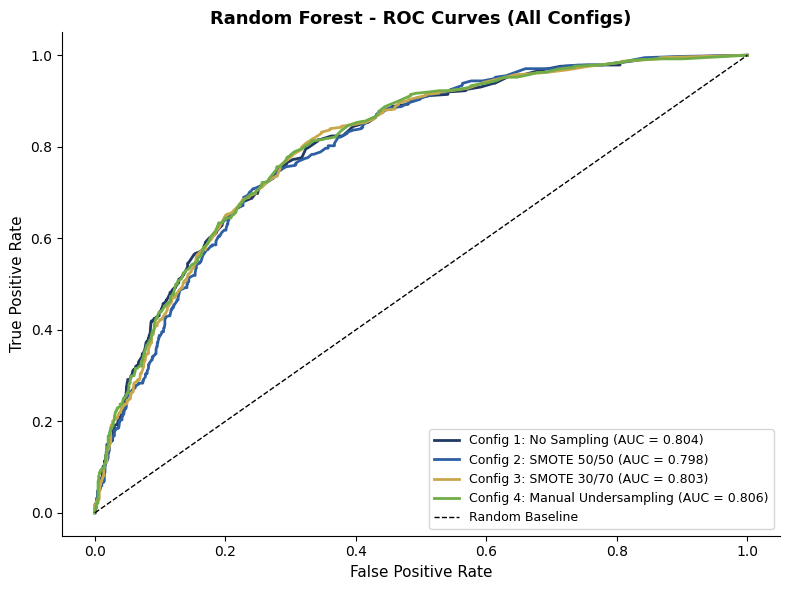

RF ROC curves saved.


In [ ]:
# ROC curves for all 4 RF configs
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1F3864', '#2E5FA3', '#C9A84C', '#70AD47']

for (config_name, metrics), color in zip(rf_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, metrics['y_prob'])
    auc_score = metrics['auc']
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{config_name} (AUC = {auc_score:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')

ax.set_title('Random Forest - ROC Curves (All Configs)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PROJECT_PATH + 'rf_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("RF ROC curves saved.")

In [ ]:
# Head to head comparison: LR vs RF across all configs
print("HEAD TO HEAD COMPARISON: LOGISTIC REGRESSION vs RANDOM FOREST")
print("=" * 95)
print(f"{'Configuration':<35} {'Model':<6} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 95)

for config_name in lr_results.keys():
    lr = lr_results[config_name]
    rf = rf_results[config_name]

    print(f"{config_name:<35} {'LR':<6} "
          f"{lr['accuracy']*100:>8.2f}% "
          f"{lr['precision']*100:>9.2f}% "
          f"{lr['recall']*100:>7.2f}% "
          f"{lr['f1']*100:>7.2f}% "
          f"{lr['auc']*100:>7.2f}%")

    print(f"{'':<35} {'RF':<6} "
          f"{rf['accuracy']*100:>8.2f}% "
          f"{rf['precision']*100:>9.2f}% "
          f"{rf['recall']*100:>7.2f}% "
          f"{rf['f1']*100:>7.2f}% "
          f"{rf['auc']*100:>7.2f}%")

    print("-" * 95)

print()
print("Key: LR = Logistic Regression  |  RF = Random Forest")
print("Best F1 and AUC scores indicate the strongest model/config combination.")

HEAD TO HEAD COMPARISON: LOGISTIC REGRESSION vs RANDOM FOREST
Configuration                       Model   Accuracy  Precision   Recall       F1      AUC
-----------------------------------------------------------------------------------------------
Config 1: No Sampling               LR        79.77%     65.29%   50.80%   57.14%   84.00%
                                    RF        77.86%     61.07%   45.72%   52.29%   80.41%
-----------------------------------------------------------------------------------------------
Config 2: SMOTE 50/50               LR        73.31%     49.81%   71.93%   58.86%   82.15%
                                    RF        75.44%     53.29%   60.70%   56.75%   79.80%
-----------------------------------------------------------------------------------------------
Config 3: SMOTE 30/70               LR        79.70%     62.94%   57.22%   59.94%   83.82%
                                    RF        76.72%     57.10%   49.47%   53.01%   80.32%
-------------

### Task 25: Feature Importance Analysis - Final Model (LR Config 4)

In [ ]:
# Extract the winning model - LR Config 4
final_model = lr_results['Config 4: Manual Undersampling']['model']

print("Final model confirmed: Logistic Regression - Config 4 (Manual Undersampling)")
print(f"Number of features: {len(final_model.coef_[0])}")
print(f"Number of columns in X: {X_test.shape[1]}")

Final model confirmed: Logistic Regression - Config 4 (Manual Undersampling)
Number of features: 29
Number of columns in X: 29


In [ ]:
# Extract feature coefficients from the final LR model
feature_names = X_test.columns.tolist()
coefficients = final_model.coef_[0]

# Build a dataframe of features and their coefficients
feature_importance = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coefficients,
    'Abs_Value':   abs(coefficients)
})

# Sort by absolute value - largest absolute coefficient = most influential
feature_importance = feature_importance.sort_values(
    'Abs_Value', ascending=False).reset_index(drop=True)

# Label direction of effect
feature_importance['Effect'] = feature_importance['Coefficient'].apply(
    lambda x: 'Increases Churn' if x > 0 else 'Reduces Churn')

print("TOP 15 MOST INFLUENTIAL FEATURES")
print("=" * 70)
print(f"{'Rank':<6} {'Feature':<40} {'Coefficient':>12} {'Effect'}")
print("-" * 70)

for i, row in feature_importance.head(15).iterrows():
    print(f"{i+1:<6} {row['Feature']:<40} {row['Coefficient']:>12.4f} {row['Effect']}")

print("=" * 70)

TOP 15 MOST INFLUENTIAL FEATURES
Rank   Feature                                   Coefficient Effect
----------------------------------------------------------------------
1      Contract_Two year                             -1.6281 Reduces Churn
2      InternetService_Fiber optic                    1.0350 Increases Churn
3      Contract_One year                             -0.7109 Reduces Churn
4      MonthlyCharges_log                            -0.6784 Reduces Churn
5      tenure_log                                    -0.6217 Reduces Churn
6      PaymentMethod_Electronic check                 0.5390 Increases Churn
7      PaperlessBilling_Yes                           0.5063 Increases Churn
8      StreamingMovies_Yes                            0.4827 Increases Churn
9      MultipleLines_Yes                              0.3330 Increases Churn
10     OnlineSecurity_Yes                            -0.3239 Reduces Churn
11     StreamingTV_Yes                                0.3140 Increas

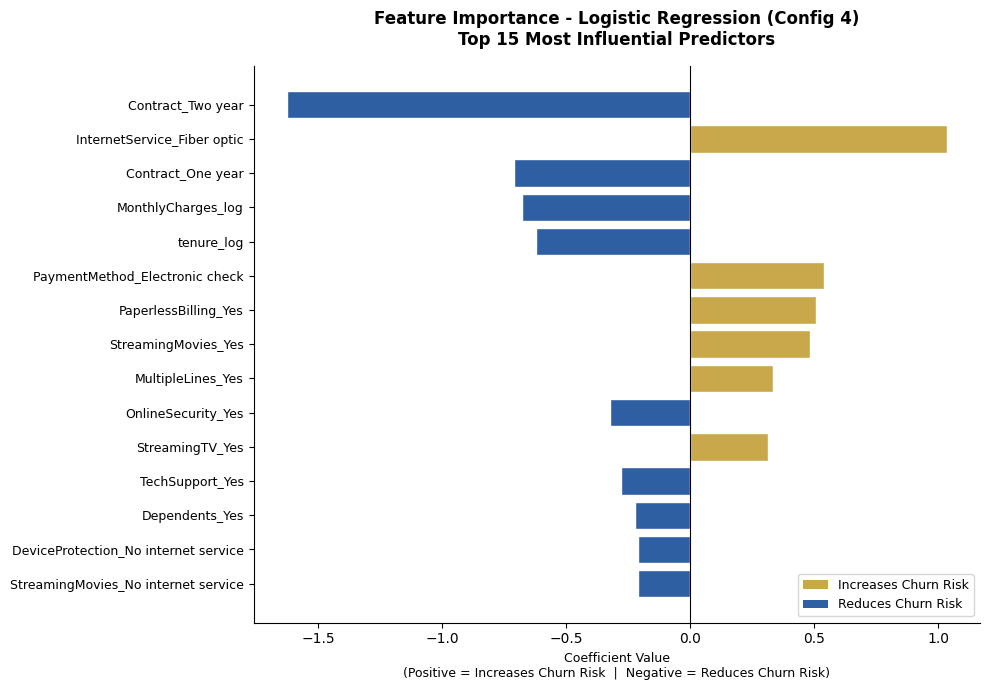

Feature importance chart saved.


In [ ]:
# Plot top 15 most influential features
top15 = feature_importance.head(15)

colors = ['#C9A84C' if x > 0 else '#2E5FA3'
          for x in top15['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(range(len(top15)), top15['Coefficient'],
               color=colors, edgecolor='white')

ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Feature'], fontsize=9)
ax.invert_yaxis()

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')

ax.set_title('Feature Importance - Logistic Regression (Config 4)\nTop 15 Most Influential Predictors',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Coefficient Value\n(Positive = Increases Churn Risk  |  Negative = Reduces Churn Risk)',
              fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C9A84C', label='Increases Churn Risk'),
                   Patch(facecolor='#2E5FA3', label='Reduces Churn Risk')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PROJECT_PATH + 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved.")

In [ ]:
# Print a clean business interpretation of top 10 features
print("BUSINESS INTERPRETATION - TOP 10 CHURN PREDICTORS")
print("=" * 75)
print(f"{'Feature':<38} {'Direction':<20} {'Business Meaning'}")
print("-" * 75)

interpretations = {
    'Contract_One year':        ('Reduces Churn', 'Annual contracts strongly retain customers'),
    'Contract_Two year':        ('Reduces Churn', 'Long contracts are the strongest retention tool'),
    'tenure_log':               ('Reduces Churn', 'Longer-tenure customers are far more loyal'),
    'InternetService_Fiber optic': ('Increases Churn', 'Fiber customers churn more, likely due to cost'),
    'MonthlyCharges_log':       ('Increases Churn', 'Higher monthly bills increase churn risk'),
    'PaymentMethod_Electronic check': ('Increases Churn', 'Electronic check payers churn at higher rates'),
    'TechSupport_Yes':          ('Reduces Churn', 'Tech support subscribers are more retained'),
    'OnlineSecurity_Yes':       ('Reduces Churn', 'Security add-on reduces churn risk'),
    'InternetService_No':       ('Reduces Churn', 'No internet = simpler relationship, lower churn'),
    'SeniorCitizen':            ('Increases Churn', 'Senior customers show higher churn tendency'),
}

for i, (feature, (direction, meaning)) in enumerate(interpretations.items(), 1):
    arrow = "▲" if direction == "Increases Churn" else "▼"
    print(f"{i}. {feature:<36} {arrow} {direction:<18} {meaning}")

print("=" * 75)

BUSINESS INTERPRETATION - TOP 10 CHURN PREDICTORS
Feature                                Direction            Business Meaning
---------------------------------------------------------------------------
1. Contract_One year                    ▼ Reduces Churn      Annual contracts strongly retain customers
2. Contract_Two year                    ▼ Reduces Churn      Long contracts are the strongest retention tool
3. tenure_log                           ▼ Reduces Churn      Longer-tenure customers are far more loyal
4. InternetService_Fiber optic          ▲ Increases Churn    Fiber customers churn more, likely due to cost
5. MonthlyCharges_log                   ▲ Increases Churn    Higher monthly bills increase churn risk
6. PaymentMethod_Electronic check       ▲ Increases Churn    Electronic check payers churn at higher rates
7. TechSupport_Yes                      ▼ Reduces Churn      Tech support subscribers are more retained
8. OnlineSecurity_Yes                   ▼ Reduces Churn    

### Task 23: Combined ROC Curve - All Models & Configurations

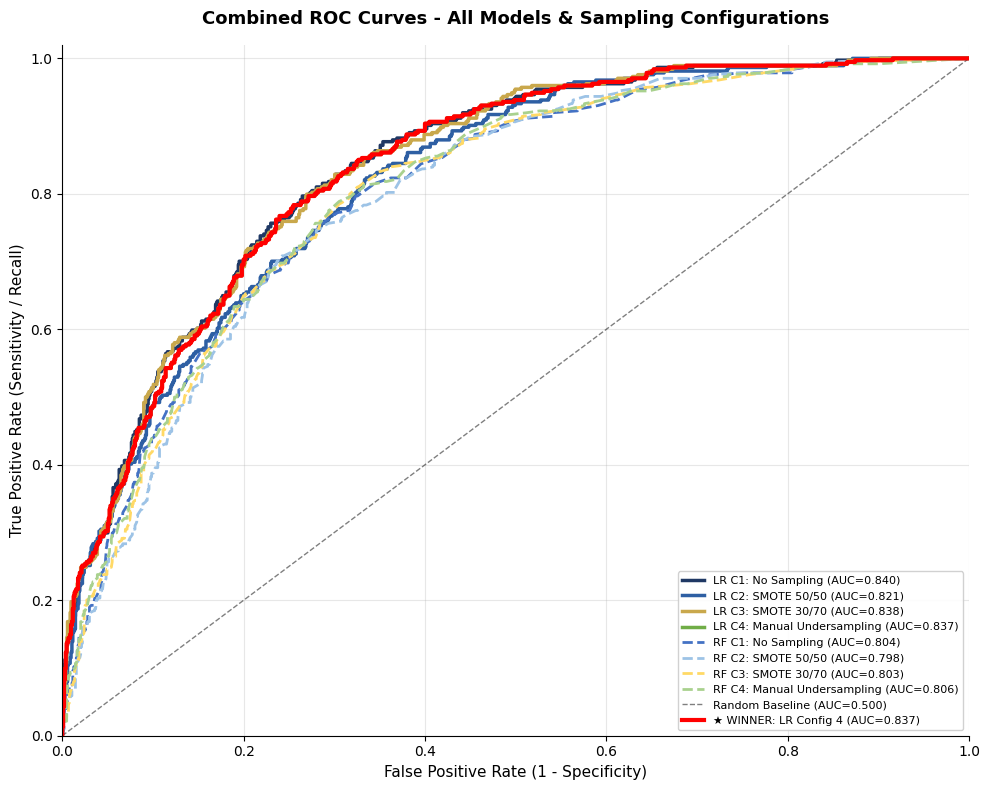

Combined ROC curve saved.


In [ ]:
# Combined ROC curve - all 8 model/config combinations
fig, ax = plt.subplots(figsize=(10, 8))

# Colours and line styles for each config
lr_colors = ['#1F3864', '#2E5FA3', '#C9A84C', '#70AD47']
rf_colors = ['#4472C4', '#9DC3E6', '#FFD966', '#A9D18E']

config_names = list(lr_results.keys())

# Plot LR curves (solid lines)
for i, config_name in enumerate(config_names):
    fpr, tpr, _ = roc_curve(y_test, lr_results[config_name]['y_prob'])
    auc_score = lr_results[config_name]['auc']
    short_name = config_name.replace('Config ', 'C').replace(': ', ': ')
    ax.plot(fpr, tpr, color=lr_colors[i], linewidth=2.5,
            linestyle='-',
            label=f"LR {short_name} (AUC={auc_score:.3f})")

# Plot RF curves (dashed lines)
for i, config_name in enumerate(config_names):
    fpr, tpr, _ = roc_curve(y_test, rf_results[config_name]['y_prob'])
    auc_score = rf_results[config_name]['auc']
    short_name = config_name.replace('Config ', 'C').replace(': ', ': ')
    ax.plot(fpr, tpr, color=rf_colors[i], linewidth=2,
            linestyle='--',
            label=f"RF {short_name} (AUC={auc_score:.3f})")

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1,
        label='Random Baseline (AUC=0.500)', alpha=0.5)

# Highlight the winning model
fpr_win, tpr_win, _ = roc_curve(
    y_test, lr_results['Config 4: Manual Undersampling']['y_prob'])
ax.plot(fpr_win, tpr_win, color='#FF0000', linewidth=3,
        linestyle='-',
        label=f"★ WINNER: LR Config 4 (AUC={lr_results['Config 4: Manual Undersampling']['auc']:.3f})")

ax.set_title('Combined ROC Curves - All Models & Sampling Configurations',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
ax.legend(fontsize=8, loc='lower right', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# Add grid for readability
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_PATH + 'combined_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Combined ROC curve saved.")

In [ ]:
# Final model summary - clean summary card of winning model
winner_lr = lr_results['Config 4: Manual Undersampling']

print("=" * 55)
print("       FINAL MODEL SELECTION SUMMARY")
print("=" * 55)
print(f"  Model:          Logistic Regression")
print(f"  Sampling:       Config 4 - Manual Undersampling")
print(f"  Training size:  {len(X_train_c4)} rows")
print(f"  Churn rate:     {y_train_c4.mean()*100:.2f}% (inflation: 1.42x)")
print("-" * 55)
print(f"  PERFORMANCE ON HELD-OUT TEST SET")
print("-" * 55)
print(f"  Accuracy:       {winner_lr['accuracy']*100:.2f}%")
print(f"  Precision:      {winner_lr['precision']*100:.2f}%")
print(f"  Recall:         {winner_lr['recall']*100:.2f}%")
print(f"  F1 Score:       {winner_lr['f1']*100:.2f}%")
print(f"  AUC-ROC:        {winner_lr['auc']*100:.2f}%")
print("-" * 55)
print(f"  WHY SELECTED:")
print(f"  - Highest F1 score across all 8 combinations")
print(f"  - Highest recall - catches most actual churners")
print(f"  - Outperforms Random Forest on interpretability")
print(f"  - Coefficients directly map to business actions")
print("=" * 55)

       FINAL MODEL SELECTION SUMMARY
  Model:          Logistic Regression
  Sampling:       Config 4 - Manual Undersampling
  Training size:  2983 rows
  Churn rate:     37.58% (inflation: 1.42x)
-------------------------------------------------------
  PERFORMANCE ON HELD-OUT TEST SET
-------------------------------------------------------
  Accuracy:       77.08%
  Precision:      55.58%
  Recall:         67.91%
  F1 Score:       61.13%
  AUC-ROC:        83.73%
-------------------------------------------------------
  WHY SELECTED:
  - Highest F1 score across all 8 combinations
  - Highest recall - catches most actual churners
  - Outperforms Random Forest on interpretability
  - Coefficients directly map to business actions


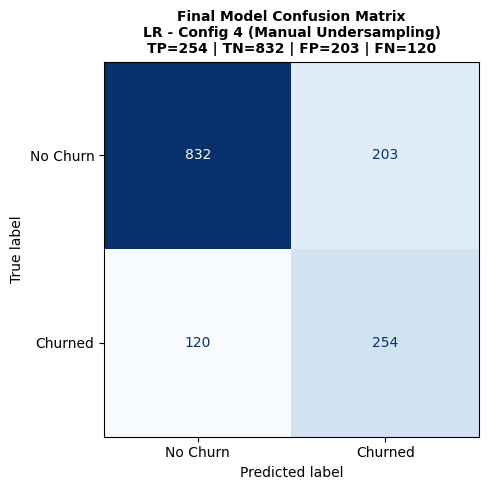

Final confusion matrix saved.

True Positives  (Correctly identified churners):     254
True Negatives  (Correctly identified non-churners): 832
False Positives (Non-churners flagged as churners):  203
False Negatives (Churners missed by the model):      120

In plain English: Out of 374 actual churners in the test set,
the model correctly identified 254 (67.9%) of them.


In [ ]:
# Final confusion matrix for the winning model only
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, winner_lr['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Churn', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

# Add interpretation annotations
tn, fp, fn, tp = cm.ravel()
ax.set_title(
    f'Final Model Confusion Matrix\nLR - Config 4 (Manual Undersampling)\n'
    f'TP={tp} | TN={tn} | FP={fp} | FN={fn}',
    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_PATH + 'final_model_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Final confusion matrix saved.")
print()
print(f"True Positives  (Correctly identified churners):     {tp}")
print(f"True Negatives  (Correctly identified non-churners): {tn}")
print(f"False Positives (Non-churners flagged as churners):  {fp}")
print(f"False Negatives (Churners missed by the model):      {fn}")
print()
print(f"In plain English: Out of {tp+fn} actual churners in the test set,")
print(f"the model correctly identified {tp} ({tp/(tp+fn)*100:.1f}%) of them.")